In [1]:
import numpy as np
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from rdkit.Chem import Draw
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr

# Supp fig 11

In [6]:
combinations = [
    ["BXPC3", "CAPAN2"],
    ["BXPC3", "HEK293"],
    ["CAPAN2", "HEK293"],
    ["CAPAN2", "CFPAC1"],
    ["HEK293", "BXPC3"],
    ["HEK293", "CAPAN2"],
    ["HEK293", "CFPAC1"],
]

clls = ["BXPC3", "CAPAN2", "HEK293", "CFPAC1"]

thresholds = {"CAPAN2": 30.9, "BXPC3": 21.95, "CFPAC1": 35.05, "HEK293": 48.15}

In [2]:
expected_results = pd.read_csv('../extra_data/expected_outcome_generated_molecules_tested.csv')

In [3]:
cpd2inchi = dict(zip(expected_results['ID'], expected_results['inchi']))

In [4]:
cpds_that_worked = {
    "BXPC3_vs_CAPAN2": [
        "Z3025619666",
        "MCULE-1153524502",
        "MCULE-2326121181",
        "MCULE-5074289166",
        "MCULE-5830374764",
        "MCULE-3283587573",
        "MCULE-1477843803",
        "MCULE-2040607482",
        "MCULE-3551346871",
        "MCULE-1329921853",
     ],
    # 'MCULE-1153524502', 'MCULE-1329921853', 'MCULE-1477843803',
    #     'MCULE-2040607482', 'MCULE-2326121181', 'MCULE-3283587573',
    #     'MCULE-3551346871', 'MCULE-5074289166', 'MCULE-5830374764',
    #     'MCULE-6814427357', 'MCULE-8454725046', 'Z3025619666'],
    "BXPC3_vs_HEK293": ["F16 [36098-33-6]"],
    "HEK293_vs_BXPC3": ["MCULE-6767457754"],
    "HEK293_vs_CAPAN2": ["MCULE-6767457754"],
    "HEK293_vs_CFPAC1": [
        "MCULE-8388595355",
        'S-889085176',
        "MCULE-1508380250",
        "MCULE-2557790400",
        "MCULE-1493650762",
    ],
}

In [5]:
def smiles_to_fingerprint(smiles_list):
    """
    Convert a list of SMILES strings to molecular fingerprints.
    """
    fingerprints = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fingerprint = AllChem.GetMorganFingerprintAsBitVect(
                mol, 2, nBits=2048
            )  # Morgan fingerprint with radius 2
            fingerprints.append(fingerprint)
        else:
            print(f"Invalid SMILES string: {smiles}")
    return fingerprints


def compute_tanimoto_similarity(fingerprint1, fingerprint2):
    """
    Compute the Tanimoto similarity between two fingerprints.
    """
    return AllChem.DataStructs.TanimotoSimilarity(fingerprint1, fingerprint2)

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem

global_results = pd.DataFrame()
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    
    generated_cpds_vs_to_buy = pd.read_csv(
        "../extra_data/generated_molecules/high_scoring_cpds_found_in_dbs_%s_vs_%s.csv"
        % (pos_cll, neg_cll)
    )
    if pos_cll == "BXPC3" and neg_cll == "CAPAN2":
        generated_cpds_vs_to_buy.loc[len(generated_cpds_vs_to_buy)] = {'id':'MCULE-6325569038', 'qrySmiles': 'N(c1ccccc1)C(c1sc2c(cc3c(n2)CCCC3)c1N)=O', 'hitSmiles':'C1(C(=O)NC2=CC=C(C=C2)C)=C(N)C2=C(N=C3C(CCCC3)=C2)S1', 'tanimoto_gen_vs_to_buy':0.989, 'exercise':'BXPC3_vs_CAPAN2'}
        # When buying the molecules, they couldn't provide the original one found and changed it for this one
    if pos_cll != "CAPAN2":
        cpds = cpds_that_worked[pos_cll + "_vs_" + neg_cll]
        print(cpds)
        
        inchis_worked = [cpd2inchi[s] for s in cpds]

        tanimotos_worked = []
        tanimotos_manual_worked = []
        max_tanimotos_worked = []
        for n, s in enumerate(inchis_worked):
            tanimotos_worked.append(
                max(
                    generated_cpds_vs_to_buy["tanimoto_gen_vs_to_buy"].values[
                        generated_cpds_vs_to_buy["inchi_to_buy"] == s
                    ]
                )
            )

            # Compute tanimotos manually
            mol1 = Chem.MolFromInchi(s)
            fp1 = AllChem.GetMorganFingerprintAsBitVect(
                mol1, 2, nBits=1024
            )  # Morgan fingerprint with radius 2
            qry_inchis = generated_cpds_vs_to_buy["qryInchis"].values[
                generated_cpds_vs_to_buy["inchi_to_buy"] == s
            ]
            qry_mols = [Chem.MolFromInchi(a) for a in qry_inchis]
            qry_fps = [
                AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
                for mol in qry_mols
            ]

            qry_tanimotos = [compute_tanimoto_similarity(fp1, fp) for fp in qry_fps]
            tanimotos_manual_worked.append(max(qry_tanimotos))

            max_tanimotos_worked.append(
                max(tanimotos_manual_worked[-1], tanimotos_worked[-1])
            )

        

    else:
        cpds = []
        max_tanimotos_worked = []

    tanimotos_noworked = []
    tanimotos_manual_noworked = []
    max_tanimotos_noworked = []
    # Get inchis that didn't work
    expected = (
        expected_results[["ID", pos_cll, neg_cll]]
        .sort_values(by="ID")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]
    cpds_noworked = expected["ID"][~expected["ID"].isin(cpds)]
    inchis_noworked = [cpd2inchi[s] for s in cpds_noworked]

    for n, s in enumerate(inchis_noworked):
        tanimotos_noworked.append(
            max(
                generated_cpds_vs_to_buy["tanimoto_gen_vs_to_buy"].values[
                    generated_cpds_vs_to_buy["inchi_to_buy"] == s
                ]
            )
        )

        # Compute tanimotos manually
        mol1 = Chem.MolFromInchi(s)
        fp1 = AllChem.GetMorganFingerprintAsBitVect(
            mol1, 2, nBits=1024
        )  # Morgan fingerprint with radius 2
        qry_inchis = generated_cpds_vs_to_buy["qryInchis"].values[
            generated_cpds_vs_to_buy["inchi_to_buy"] == s
        ]
        qry_mols = [Chem.MolFromInchi(a) for a in qry_inchis]
        qry_fps = [
            AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
            for mol in qry_mols
        ]

        qry_tanimotos = [compute_tanimoto_similarity(fp1, fp) for fp in qry_fps]
        tanimotos_manual_noworked.append(max(qry_tanimotos))

        max_tanimotos_noworked.append(
            max(tanimotos_manual_noworked[-1], tanimotos_noworked[-1])
        )

    data = pd.DataFrame()
    data["cpd"] = list(cpds) + list(cpds_noworked)
    data["Hit"] = [1] * len(cpds) + [0] * len(cpds_noworked)
    data["tanimotos"] = max_tanimotos_worked + max_tanimotos_noworked
    data["exercise"] = [c[0] + "_vs_" + c[1]] * len(data)

    global_results = pd.concat([global_results, data], ignore_index=True)

['Z3025619666', 'MCULE-1153524502', 'MCULE-2326121181', 'MCULE-5074289166', 'MCULE-5830374764', 'MCULE-3283587573', 'MCULE-1477843803', 'MCULE-2040607482', 'MCULE-3551346871', 'MCULE-1329921853']
['F16 [36098-33-6]']


[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerator
[10:31:56] DEPRECATION WARNING: please use MorganGenerat

['MCULE-6767457754']
['MCULE-6767457754']
['MCULE-8388595355', 'S-889085176', 'MCULE-1508380250', 'MCULE-2557790400', 'MCULE-1493650762']


[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerator
[10:31:57] DEPRECATION WARNING: please use MorganGenerat

In [12]:
results = pd.read_excel(
    "../../drug screening data/Validation of generated molecules vs prediction only approach.xlsx", sheet_name = 'Validation of NCEs'
)
results.head()

,SMILES,Supplier,Supplier Ref,Conc,% Inh BXPC3 rep1,% Inh BXPC3 rep2,% Inh BXPC3 rep3,% Inh CAPAN2 rep1,% Inh CAPAN2 rep2,% Inh CAPAN2 rep3,% Inh CFPAC1 rep1,% Inh CFPAC1 rep2,% Inh CFPAC1 rep3,% Inh HEK293 rep1,% Inh HEK293 rep2,% Inh HEK293 rep3
0,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,1 uM,-2.2013,4.9652,7.4744,-5.4366,-3.97960,-1.56220,0.97032,-7.1862,8.7617,21.5260,19.5270,21.0300
1,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,10 uM,38.8470,26.4810,34.3020,12.9220,10.87800,-0.23526,27.18500,29.5070,20.9840,67.2060,61.1630,60.7760
2,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,1 uM,-4.3469,-1.3673,-14.6870,-6.1786,-0.21616,-2.90370,-4.56420,-3.6454,-12.4590,6.5656,6.1441,3.9810
3,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,10 uM,23.9910,18.6080,23.3690,9.5590,6.50400,14.46100,20.70500,9.1902,19.4930,67.5150,63.0500,61.4010
4,C1(C(=O)NC2=CC=C(C=C2)C)=C(N)C2=C(N=C3C(CCCC3)...,Mcule,MCULE-6325569038,1 uM,-11.0200,3.1101,-6.7132,-10.9430,-4.36140,-9.13320,2.20460,-3.4436,-2.4091,-7.3113,4.9472,-9.5225


In [13]:
r10uM = results[
    results["Conc"] == "10 uM"
]

In [14]:
r1uM = results[
    results["Conc"] == "1 uM"
]

In [15]:
r10uM.head()

,SMILES,Supplier,Supplier Ref,Conc,% Inh BXPC3 rep1,% Inh BXPC3 rep2,% Inh BXPC3 rep3,% Inh CAPAN2 rep1,% Inh CAPAN2 rep2,% Inh CAPAN2 rep3,% Inh CFPAC1 rep1,% Inh CFPAC1 rep2,% Inh CFPAC1 rep3,% Inh HEK293 rep1,% Inh HEK293 rep2,% Inh HEK293 rep3
1,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,10 uM,38.84700,26.4810,34.3020,12.9220,10.8780,-0.23526,27.1850,29.5070,20.9840,67.206,61.1630,60.77600
3,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,10 uM,23.99100,18.6080,23.3690,9.5590,6.5040,14.46100,20.7050,9.1902,19.4930,67.515,63.0500,61.40100
5,C1(C(=O)NC2=CC=C(C=C2)C)=C(N)C2=C(N=C3C(CCCC3)...,Mcule,MCULE-6325569038,10 uM,0.68191,9.0291,1.2149,4.0505,1.9235,-5.45210,-7.2467,-3.4078,4.2275,18.214,18.7430,13.24100
7,C1(C=CC(=CC=1O)O)C=NC1=CC=C(C=C1)N(C)C,Mcule,MCULE-3518770215,10 uM,-1.09750,5.3537,7.2896,7.2977,4.5338,-2.51630,-0.6249,5.5343,4.2189,-2.026,-4.6649,-0.66613
9,C12C(C)=CC=C(C)C=1C(C)=NC1C=C(C=CC=1S2)C(=O)NC...,Mcule,MCULE-7427575619,10 uM,65.52700,64.0570,68.9450,30.7140,37.8620,25.17400,50.5130,57.0340,51.7270,65.168,64.9390,59.14200


In [16]:
clls = ['CAPAN2', 'BXPC3', 'CFPAC1', 'HEK293']
# Aggregate replicates
for cll in clls:
    replicates = r10uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r10uM[cll + "_mean"] = replicates.mean(axis=1)
    r10uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_57980/1759669314.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_57980/1759669314.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_57980/1759669314.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_57980/1759669314.py:13: FutureWarning: Series.__getitem__ treating keys as positions is depre

In [17]:
# Aggregate replicates
for cll in clls:
    replicates = r1uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r1uM[cll + "_mean"] = replicates.mean(axis=1)
    r1uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_57980/1274348408.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_57980/1274348408.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_57980/1274348408.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_57980/1274348408.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprec

In [18]:
global_results[global_results['tanimotos']<1].cpd.nunique()

34

In [19]:
global_results[global_results['tanimotos']==1].cpd.nunique()

15

In [20]:
global_results.shape

(53, 4)

In [21]:
global_results.cpd.nunique()

45

In [23]:
global_results['exercise'].value_counts()

exercise
BXPC3_vs_HEK293     22
BXPC3_vs_CAPAN2     16
HEK293_vs_CFPAC1    11
CAPAN2_vs_HEK293     1
CAPAN2_vs_CFPAC1     1
HEK293_vs_BXPC3      1
HEK293_vs_CAPAN2     1
Name: count, dtype: int64

In [24]:
thresholds = {
    "CAPAN2": 30.9,
    "SW1990": 36.89,
    "BXPC3": 21.95,
    "HPAFII": 20.89,
    "CFPAC1": 35.05,
    "PANC10.05": 27.26,
    "HEK293": 48.15,
}

In [25]:
combinations = [c[0]+'_vs_'+c[1] for c in combinations]

In [28]:
global_results.head()

,cpd,Hit,tanimotos,exercise
0,Z3025619666,1,0.972875,BXPC3_vs_CAPAN2
1,MCULE-1153524502,1,0.961468,BXPC3_vs_CAPAN2
2,MCULE-2326121181,1,0.902527,BXPC3_vs_CAPAN2
3,MCULE-5074289166,1,0.960000,BXPC3_vs_CAPAN2
4,MCULE-5830374764,1,0.952741,BXPC3_vs_CAPAN2


In [34]:
from scipy.stats import pearsonr

all_rows = []

for ex in combinations:
    cl1, cl2 = ex.split('_vs_')

    aux = global_results[
        (global_results['exercise'] == ex) 
        # &(global_results['worked'] == 1)
    ]

    # --- 10 µM ---
    merged_10 = pd.merge(aux, r10uM, left_on='cpd',right_on="Supplier Ref", how="inner")

    merged_10['deltas_affected'] = (
        merged_10[f"{cl1}_mean2closest"] - thresholds[cl1]
    )
    merged_10['deltas_unaffected'] = (
        merged_10[f"{cl2}_mean2closest"] - thresholds[cl2]
    )

    merged_10['exercise'] = ex
    merged_10['concentration'] = '10uM'

    all_rows.append(
        merged_10[
            ['cpd', 'exercise', 'concentration',
             'tanimotos', 'deltas_affected', 'deltas_unaffected']
        ]
    )

    # --- 1 µM ---
    merged_1 = pd.merge(aux, r1uM,left_on='cpd',right_on="Supplier Ref", how="inner")

    merged_1['deltas_affected'] = (
        merged_1[f"{cl1}_mean2closest"] - thresholds[cl1]
    )
    merged_1['deltas_unaffected'] = (
        merged_1[f"{cl2}_mean2closest"] - thresholds[cl2]
    )

    merged_1['exercise'] = ex
    merged_1['concentration'] = '1uM'

    all_rows.append(
        merged_1[
            ['cpd', 'exercise', 'concentration',
             'tanimotos', 'deltas_affected', 'deltas_unaffected']
        ]
    )

# 🔹 Final dataframe with ALL compounds
deltas_df = pd.concat(all_rows, ignore_index=True)


In [35]:
plot_df = deltas_df[deltas_df['concentration'] == '10uM']
plot_df = plot_df.sort_values('tanimotos', ascending=False)

In [32]:
plot_df['delta_combined'] = (
    plot_df['deltas_affected'] - plot_df['deltas_unaffected']
)

if len(plot_df) > 1:
    r, p = pearsonr(plot_df['tanimotos'], plot_df['delta_combined'])
    print(f"Global Pearson r = {r:.2f}, p = {p:.2g}")


Global Pearson r = 0.27, p = 0.049


In [36]:
deltas_df.head(2)

,cpd,exercise,concentration,tanimotos,deltas_affected,deltas_unaffected
0,Z3025619666,BXPC3_vs_CAPAN2,10uM,0.972875,43.3375,-4.3430
1,MCULE-1153524502,BXPC3_vs_CAPAN2,10uM,0.961468,34.5790,4.4795


In [37]:
deltas_df['worked'] = np.logical_and(deltas_df['deltas_affected']>=0,deltas_df['deltas_unaffected']<=0)*1
deltas_df.worked.sum()

np.int64(21)

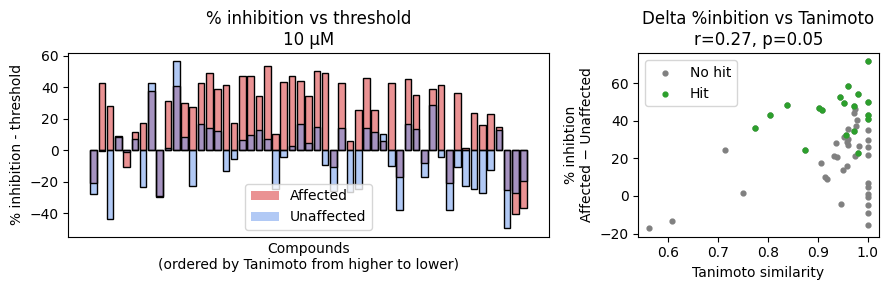

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={'width_ratios': [2, 1]})

# ---------- 10 µM ----------
df10 = deltas_df[deltas_df['concentration'] == '10uM'].drop_duplicates()
df10 = df10.sort_values('tanimotos', ascending=False)

x10 = np.arange(len(df10))

ax1.bar(x10, df10['deltas_affected'],
        color='tab:red', alpha=0.5, label='Affected', zorder=2)
ax1.bar(x10, df10['deltas_unaffected'],
        color='cornflowerblue', alpha=0.5, label='Unaffected', zorder=2)

# outlines
ax1.bar(x10, df10['deltas_affected'], fill=False, edgecolor='black', zorder=3)
ax1.bar(x10, df10['deltas_unaffected'], fill=False, edgecolor='black', zorder=3)

ax1.set_title('% inhibition vs threshold\n10 µM')
ax1.set_xticks([])
ax1.legend()

# ---------- 1 µM ----------
# df1 = deltas_df[deltas_df['concentration'] == '1uM']
# df1 = df1.sort_values('tanimotos', ascending=False)

# x1 = np.arange(len(df1))

# ax2.bar(x1, df1['deltas_affected'],
#         color='tab:red', alpha=0.5, zorder=2)
# ax2.bar(x1, df1['deltas_unaffected'],
#         color='cornflowerblue', alpha=0.5, zorder=2)

# ax2.bar(x1, df1['deltas_affected'], fill=False, edgecolor='black', zorder=3)
# ax2.bar(x1, df1['deltas_unaffected'], fill=False, edgecolor='black', zorder=3)

# ax2.set_title('% inhibition vs threshold\n1 µM')
# ax2.set_xticks([])

# ---------- Combined delta vs tanimoto ----------
df10['delta_combined'] = (
    df10['deltas_affected'] - df10['deltas_unaffected']
)

ax2.scatter(
    df10['tanimotos'],
    df10['delta_combined'],
    s=12,
    # alpha=0.7,
    color='grey',
    # edgecolor='black',
    label='No hit'
)

aux = df10[df10['worked']==1]
ax2.scatter(
    aux['tanimotos'],
    aux['delta_combined'],
    s=12,
    # alpha=0.7,
    color='tab:green',
    # edgecolor='black',
    label='Hit'
)

if len(df10) > 1:
    r, p = pearsonr(df10['tanimotos'], df10['delta_combined'])
    ax2.set_title(f'Delta %inbition vs Tanimoto\nr={r:.2f}, p={p:.2f}')
else:
    ax2.set_title('Delta %%inbition vs Tanimoto')

ax2.set_xlabel('Tanimoto similarity')
ax2.set_ylabel(f'% inhibtion\nAffected − Unaffected')
ax2.legend()

ax1.set_ylabel(f'% inhibition - threshold')
ax1.set_xlabel(f'Compounds\n(ordered by Tanimoto from higher to lower)')

plt.tight_layout()
plt.show()
